## Vorhersage von Partikeln in Toki Pona

Toki Pona ist eine konstruierte Minimalsprache mit ca. 130 Wörtern. Die Grammatik basiert auf fünf Partikeln (`li`, `e`, `la`, `pi`, `o`), die als strukturelle Marker fungieren.

> **Aufgabe:** Ein Klassifikator soll vorhersagen, welche Partikel an einer entfernten Stelle im Satz stehen muss. Vergleich: Decision Tree vs. Random Forest.

Als **Features** werden Word2Vec-Vektoren der umgebenden Wörter verwendet.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay

# Reproduzierbarkeit
SEED = 42
np.random.seed(SEED)

### Daten laden

Der Datensatz stammt von [Tatoeba](https://tatoeba.org/) und enthält ca. 75.000 Sätze in Toki Pona.

In [2]:
df = pd.read_csv('tok_sentences.tsv', sep='\t', header=None, names=['id', 'lang', 'text'])
print(f'Datensatz geladen: {len(df)} Sätze')
df.head(10)

Datensatz geladen: 75707 Sätze


,id,lang,text
0,614700,tok,mi suli.
1,614702,tok,kili li tawa anpa poka kasi.
2,614704,tok,o olin e jan poka.
3,617146,tok,moku li pona. jan li pali pona lon ni.
4,617406,tok,a! o lukin e pipi kule!
5,617517,tok,meli kin li wile e unpa.
6,617566,tok,meli ni li jan seme?
7,617568,tok,ona li jan seme?
8,617577,tok,sina jan seme?
9,617581,tok,jan seme li pakala e ni?


### Word2Vec laden

Jedes Wort wird als 100-dimensionaler Vektor dargestellt. Ähnliche Wörter erhalten ähnliche Vektoren. Das vortrainierte Modell stammt von [HuggingFace](https://huggingface.co/finnnnnnnnnnnn/toki-pona-word2vec).

In [3]:
from huggingface_hub import hf_hub_download
from gensim.models import KeyedVectors

model_path = hf_hub_download(
    repo_id='finnnnnnnnnnnn/toki-pona-word2vec',
    filename='model.txt',
)
w2v = KeyedVectors.load_word2vec_format(model_path, binary=False)
print(f'Vokabular: {len(w2v)} Wörter, Vektorgröße: {w2v.vector_size}')
print(f'Ähnlichste Wörter zu "mi": {w2v.most_similar("mi", topn=5)}')

# Vorverarbeitung: Satzzeichen entfernen, Kleinbuchstaben
sentences = []
for text in df['text']:
    clean = re.sub(r'[^\w\s]', '', text.lower())
    words = clean.split()
    if words:
        sentences.append(words)

Vokabular: 297 Wörter, Vektorgröße: 100
Ähnlichste Wörter zu "mi": [('sina', 0.5385795831680298), ('pilin', 0.3945666253566742), ('o', 0.3648908734321594), ('wile', 0.3467584550380707), ('ni', 0.3141213059425354)]


### Trainingsbeispiele erzeugen

Für jede Partikel im Satz wird ein Trainingsbeispiel erstellt: Die Partikel wird entfernt und die umgebenden Wörter (je 2 links und rechts) dienen als Features.

Beispiel: `jan li moku e kili` → `jan [_] moku e kili` → Label: `li`

In [4]:
PARTICLES = {'li', 'e', 'la', 'pi', 'o'}
WINDOW = 2
VEC_SIZE = w2v.vector_size
PAD_VEC = np.zeros(VEC_SIZE)

X_list = []
y_list = []

for words in sentences:
    for i, word in enumerate(words):
        if word in PARTICLES:
            # Kontextwörter sammeln
            context = []
            for j in range(i - WINDOW, i):
                context.append(words[j] if 0 <= j < len(words) else '<PAD>')
            for j in range(i + 1, i + 1 + WINDOW):
                context.append(words[j] if j < len(words) else '<PAD>')
            
            # Wörter in Vektoren umwandeln
            vecs = [w2v[w] if w in w2v else PAD_VEC for w in context]
            X_list.append(np.concatenate(vecs))  # 4 × 100 = 400 Features
            y_list.append(word)

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list)

print(f'Beispiele: {len(X)}, Features: {X.shape[1]}')
print(f'Verteilung der Partikeln:')
for p, c in zip(*np.unique(y, return_counts=True)):
    print(f'  {p}: {c}')

Beispiele: 158503, Features: 400
Verteilung der Partikeln:
  e: 47460
  la: 20052
  li: 62386
  o: 8811
  pi: 19794


### Train/Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f'Train: {len(X_train)}, Test: {len(X_test)}')

Train: 126802, Test: 31701


---
## Decision Tree

In [6]:
dt = DecisionTreeClassifier(random_state=SEED)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

f1_dt = f1_score(y_test, y_pred_dt, average='weighted')
print(f'Decision Tree – Test F1: {f1_dt:.3f}')
print(classification_report(y_test, y_pred_dt, zero_division=0))

Decision Tree – Test F1: 0.888
              precision    recall  f1-score   support

           e       0.93      0.94      0.94      9492
          la       0.85      0.84      0.85      4011
          li       0.91      0.91      0.91     12477
           o       0.80      0.77      0.79      1762
          pi       0.78      0.77      0.78      3959

    accuracy                           0.89     31701
   macro avg       0.85      0.85      0.85     31701
weighted avg       0.89      0.89      0.89     31701



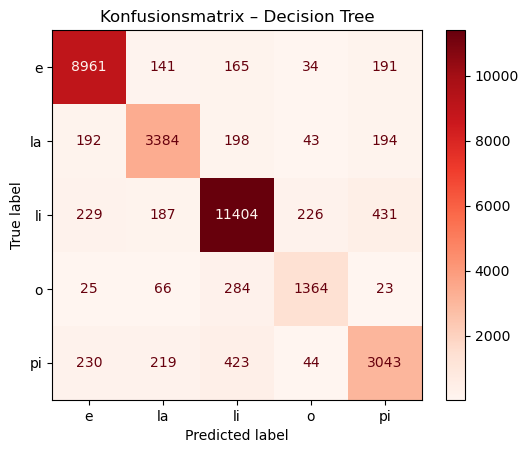

In [18]:
labels = sorted(PARTICLES)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, labels=labels, cmap='Reds')
plt.title('Konfusionsmatrix – Decision Tree')
plt.show()

---
## Random Forest

In [8]:
rf = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

f1_rf = f1_score(y_test, y_pred_rf, average='weighted')
print(f'Random Forest – Test F1: {f1_rf:.3f}')
print(classification_report(y_test, y_pred_rf, zero_division=0))

Random Forest – Test F1: 0.930
              precision    recall  f1-score   support

           e       0.96      0.97      0.96      9492
          la       0.93      0.88      0.91      4011
          li       0.93      0.96      0.94     12477
           o       0.95      0.78      0.86      1762
          pi       0.87      0.85      0.86      3959

    accuracy                           0.93     31701
   macro avg       0.93      0.89      0.91     31701
weighted avg       0.93      0.93      0.93     31701



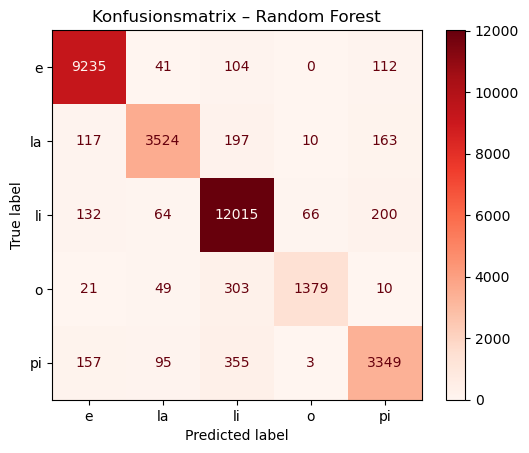

In [17]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, labels=labels, cmap='Reds')
plt.title('Konfusionsmatrix – Random Forest')
plt.show()

---
## Vergleich

Decision Tree F1: 0.888
Random Forest F1: 0.930
Besser: Random Forest


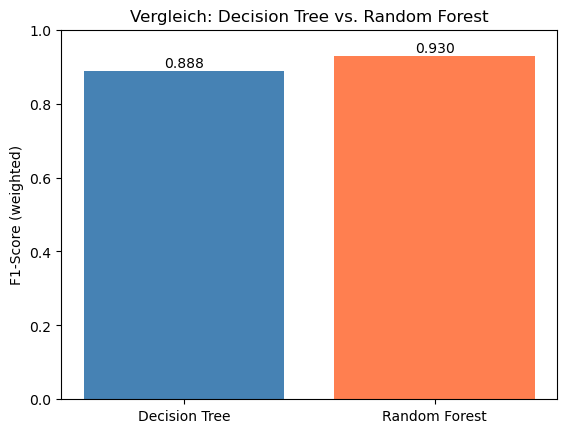

In [10]:
print(f'Decision Tree F1: {f1_dt:.3f}')
print(f'Random Forest F1: {f1_rf:.3f}')
print(f'Besser: {"Decision Tree" if f1_dt > f1_rf else "Random Forest"}')

methods = ['Decision Tree', 'Random Forest']
scores = [f1_dt, f1_rf]
plt.bar(methods, scores, color=['steelblue', 'coral'])
plt.ylabel('F1-Score (weighted)')
plt.title('Vergleich: Decision Tree vs. Random Forest')
plt.ylim(0, 1)
for i, s in enumerate(scores):
    plt.text(i, s + 0.01, f'{s:.3f}', ha='center')
plt.show()

---
## Cross-Validation

Decision Tree CV: 0.8335 (+/- 0.0040)
Random Forest CV: 0.8961 (+/- 0.0106)


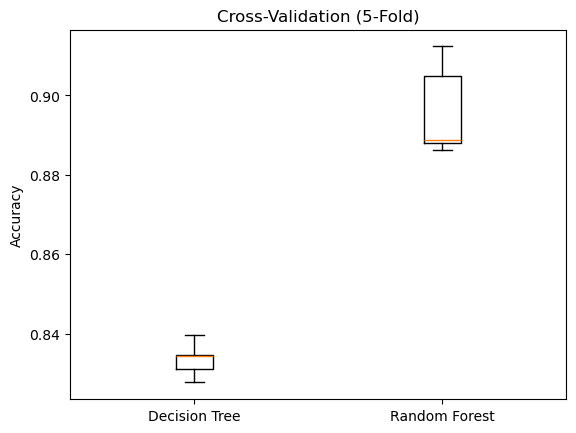

In [11]:
# Cross-Validation auf einem Subset (schneller)
subset = 15000

cv_dt = cross_val_score(dt, X[:subset], y[:subset], cv=5)
cv_rf = cross_val_score(rf, X[:subset], y[:subset], cv=5, n_jobs=-1)

print(f'Decision Tree CV: {cv_dt.mean():.4f} (+/- {cv_dt.std():.4f})')
print(f'Random Forest CV: {cv_rf.mean():.4f} (+/- {cv_rf.std():.4f})')

plt.boxplot([cv_dt, cv_rf], labels=['Decision Tree', 'Random Forest'])
plt.ylabel('Accuracy')
plt.title('Cross-Validation (5-Fold)')
plt.show()